<a href="https://colab.research.google.com/github/venkatasriharika-code/house-price-prediction/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [3]:
np.random.seed(42)
n = 500

In [4]:
data = pd.DataFrame({
    'SquareFootage': np.random.randint(600, 4000, n),
    'Bedrooms':      np.random.randint(1, 6, n),
    'Bathrooms':     np.random.randint(1, 5, n),
    'Age':           np.random.randint(1, 60, n),
    'GarageSpaces':  np.random.randint(0, 4, n),
    'DistanceToCity':np.random.uniform(1, 50, n),
})


In [5]:
data['Price'] = (
    150 * data['SquareFootage']
    + 8000  * data['Bedrooms']
    + 12000 * data['Bathrooms']
    - 500   * data['Age']
    + 7000  * data['GarageSpaces']
    - 1500  * data['DistanceToCity']
    + np.random.normal(0, 20000, n)
).clip(50000)

In [6]:
print("=" * 55)
print("   HOUSE PRICE PREDICTION — LINEAR REGRESSION")
print("=" * 55)

   HOUSE PRICE PREDICTION — LINEAR REGRESSION


In [27]:
print("\n Dataset Overview")
print(f"   Shape : {data.shape}")
print(f"   Missing values: {data.isnull().sum().sum()}")
print("\n", data.describe().round(2))


 Dataset Overview
   Shape : (500, 7)
   Missing values: 0

        SquareFootage  Bedrooms  Bathrooms     Age  GarageSpaces  \
count         500.00    500.00     500.00  500.00        500.00   
mean         2347.62      3.03       2.47   31.32          1.51   
std           967.73      1.46       1.10   16.82          1.12   
min           601.00      1.00       1.00    1.00          0.00   
25%          1555.75      2.00       1.00   17.00          1.00   
50%          2318.50      3.00       2.00   32.00          1.00   
75%          3199.50      4.00       3.00   45.00          3.00   
max          3997.00      5.00       4.00   59.00          3.00   

       DistanceToCity      Price  
count          500.00     500.00  
mean            25.58  362856.31  
std             13.99  146749.39  
min              1.16   50000.00  
25%             13.29  238443.33  
50%             26.37  358059.80  
75%             37.14  495026.28  
max             49.97  680185.13  


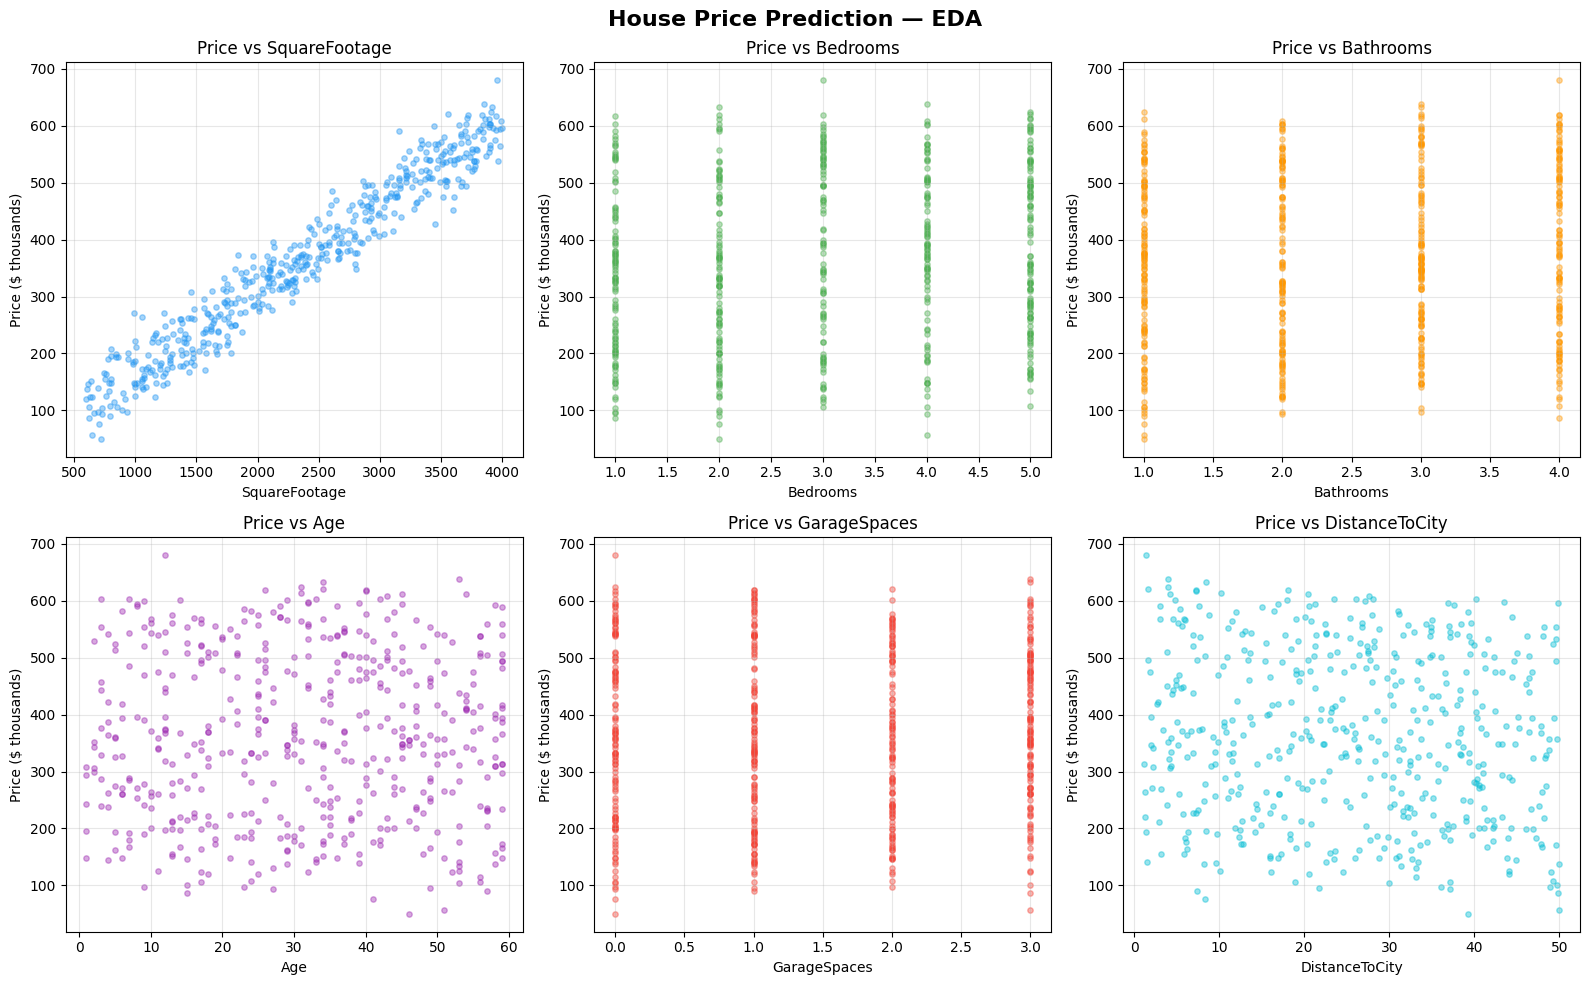

Screenshot 1 saved!


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("House Price Prediction — EDA", fontsize=16, fontweight='bold')

features = ['SquareFootage', 'Bedrooms', 'Bathrooms', 'Age', 'GarageSpaces', 'DistanceToCity']
colors   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for ax, feat, col in zip(axes.flat, features, colors):
    ax.scatter(data[feat], data['Price'] / 1000, alpha=0.4, color=col, s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('Price ($ thousands)')
    ax.set_title(f'Price vs {feat}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('screenshot1_eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Screenshot 1 saved!")

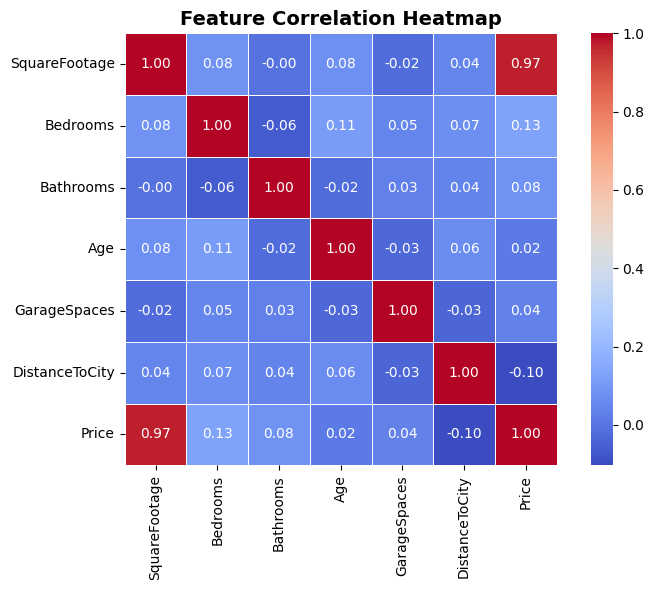

✅ Screenshot 2 saved: screenshot2_correlation_heatmap.png


In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('screenshot2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Screenshot 2 saved: screenshot2_correlation_heatmap.png")

In [13]:
X = data.drop('Price', axis=1)
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)


In [15]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

In [17]:
print("\n Model Performance")
print(f"   MAE  : {mae:,.2f}")
print(f"   RMSE : {rmse:,.2f}")
print(f"   R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")


 Model Performance
   MAE  : 16,958.22
   RMSE : 20,931.26
   R²   : 0.9793  (97.9% variance explained)


In [18]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("\n Feature Coefficients (sorted by importance):")
print(coef_df.to_string(index=False))



 Feature Coefficients (sorted by importance):
       Feature   Coefficient
 SquareFootage 142625.598785
DistanceToCity -21410.736458
     Bathrooms  13563.251784
      Bedrooms  11282.667856
           Age  -7927.933876
  GarageSpaces   6456.301057


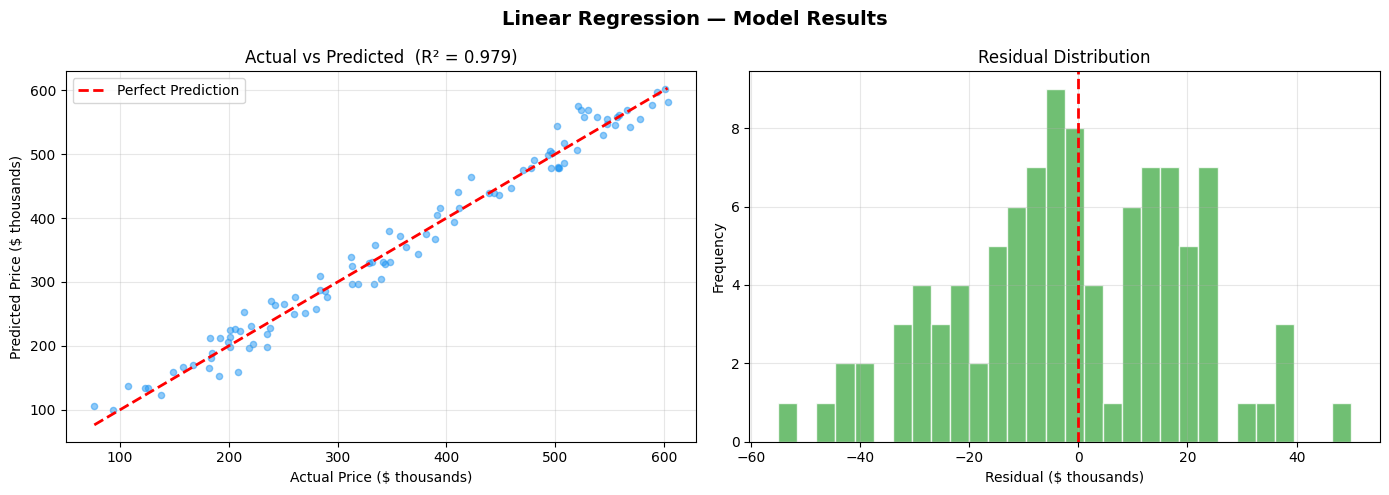


 Screenshot 3 saved: screenshot3_model_results.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Linear Regression — Model Results", fontsize=14, fontweight='bold')
ax = axes[0]
ax.scatter(y_test / 1000, y_pred / 1000, alpha=0.5, color='#2196F3', s=20)
lims = [min(y_test.min(), y_pred.min()) / 1000,
        max(y_test.max(), y_pred.max()) / 1000]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($ thousands)')
ax.set_ylabel('Predicted Price ($ thousands)')
ax.set_title(f'Actual vs Predicted  (R² = {r2:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
residuals = y_test - y_pred
ax = axes[1]
ax.hist(residuals / 1000, bins=30, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Residual ($ thousands)')
ax.set_ylabel('Frequency')
ax.set_title('Residual Distribution')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('screenshot3_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Screenshot 3 saved: screenshot3_model_results.png")

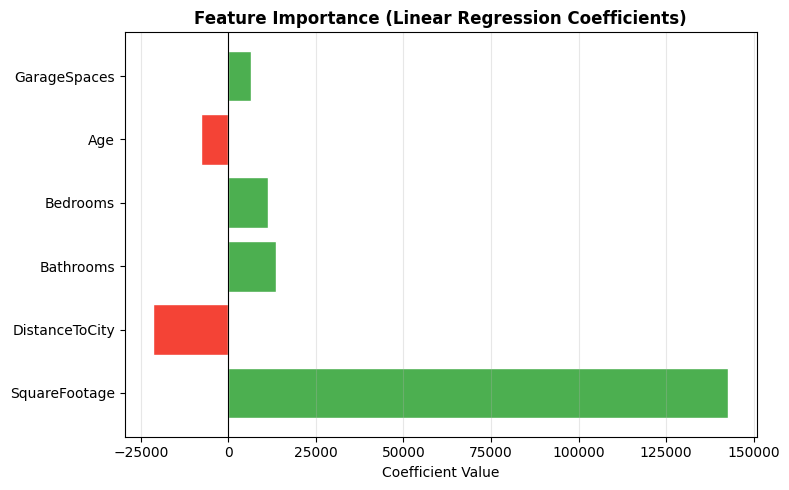

 Screenshot 4 saved: screenshot4_feature_importance.png


In [34]:
plt.figure(figsize=(8, 5))
colors_bar = ['#4CAF50' if c > 0 else '#F44336' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar, edgecolor='white')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Linear Regression Coefficients)', fontweight='bold')
plt.axvline(0, color='black', lw=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('screenshot4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Screenshot 4 saved: screenshot4_feature_importance.png")


In [35]:
print("\n Predict Price for a New House")
new_house = pd.DataFrame([{
    'SquareFootage': 1800,
    'Bedrooms':      3,
    'Bathrooms':     2,
    'Age':           10,
    'GarageSpaces':  1,
    'DistanceToCity':12.5
}])



 Predict Price for a New House


In [36]:
new_scaled    = scaler.transform(new_house)
predicted_price = model.predict(new_scaled)[0]
print(f"   Input  : {new_house.iloc[0].to_dict()}")
print(f"   Predicted Price: ${predicted_price:,.2f}")

   Input  : {'SquareFootage': 1800.0, 'Bedrooms': 3.0, 'Bathrooms': 2.0, 'Age': 10.0, 'GarageSpaces': 1.0, 'DistanceToCity': 12.5}
   Predicted Price: $303,091.17


In [37]:
print("\n" + "=" * 55)
print("   All done! 4 screenshots saved.")
print("=" * 55)



   All done! 4 screenshots saved.
